# Heatwave Policy Scenario Analysis
## Best / Average / Worst Cases × CEC Forecasts × SCM Causal Model

This notebook combines:
- **California SCM** weather sensitivities (`model/scm.py`, calibrated via `train_california.py`)
- **CEC hourly forecasts** (Planning, LocalRel, PlusKnown) as exogenous load paths
- **Year-native SCM uplift** — severity-matched heatwave on each year's climatology (primary)
- **Fleet-scaled / static 2022** benchmarks for comparison
- **`do(Weather = 2022-severity heatwave)`** at each projection year's peak hour

### Hypotheses
- **H1:** A 2022-class heatwave erodes headroom faster under LocalRel than Planning.
- **H2:** Worst-case compounding makes thermal lag and HVAC dominate weather uplift.
- **H3:** DC curtailment reduces dispatch stress; pre-cooling reduces lag-dominated uplift.
- **H4:** Combined policies recover more headroom than any single intervention (diminishing returns).

### Case definitions
| Case | CEC scenario | Sampling | Dynamic lag |
|------|--------------|----------|-------------|
| Best | Planning | Co-occurring MNL peak hour | No |
| Average | Planning–LocalRel midpoint | Co-occurring blended stress hour | No |
| Worst | LocalRel | Split: MNL peak + max core fleet | Yes |
| Envelope | LocalRel | Component-wise annual maxima | Yes |

> **Note:** CEC forecasts are **not** SCM training data. The SCM is fit on historical CAISO demand (2023–2025); CEC rows enter only as forward load scenarios.


In [1]:
import sys, json, warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

from pipeline.config import RESULTS, ANALYSIS, OBSERVED_2022_UPLIFT_MW, PRIMARY_SCENARIO
from pipeline.data.cec_loader import load_all_scenarios
from pipeline.data.sector_shares import project_sector_shares, anchor_shares_2025
from pipeline.data.weather import (
    load_weather_for_pipeline, load_hub_and_riverside, compute_climatology,
)
from pipeline.scm.heatwave_uplift import UpliftMethod, build_uplift_context
from pipeline.scm.calibration import calibrate
from pipeline.validation import run_all_validations, check_calibration_anchor
from pipeline.scenario_cases import (
    CASE_BEST, CASE_AVERAGE, CASE_WORST, CASE_ENVELOPE, ALL_CASES,
    build_sampling_diagnostics, build_stress_table, build_fleet_table,
    build_case_peak_table, compute_all_cases, compute_method_comparison,
    apply_dynamic_lag_to_trajectory, HIST_CATASTROPHIC_MW,
)
from pipeline.counterfactuals.engine import run_counterfactual, CounterfactualSpec
from pipeline.counterfactuals.scenarios import build_scenarios
from pipeline.outputs.plots import (
    fig_sector_trajectories, fig_case_stress_band, fig_headroom_erosion,
    fig_mitigation_waterfall, fig_counterfactual_matrix,
    fig_uplift_method_comparison, fig_industry_policy_matrix,
)

ANALYSIS.mkdir(parents=True, exist_ok=True)
RUN_TRAINING = False  # set True to retrain SCM (slow); default loads calibrated constants

print('Setup complete.')


Setup complete.


## §1 — SCM Verification
Load existing training metrics. The SCM is **not** retrained on CEC forecasts.


In [2]:
summary_path = RESULTS / 'summary.json'
if summary_path.exists():
    with open(summary_path) as f:
        scm_summary = json.load(f)
    print('SCM training summary (historical CAISO 2023–2025):')
    for k in ['region', 'note', 'train_mape', 'test_mape', 'cv_mape_mean']:
        if k in scm_summary:
            print(f'  {k}: {scm_summary[k]}')
    if 'train' in scm_summary:
        t = scm_summary['train']
        print(f"  Train top-1% MAPE: {t.get('top1_mape', 'n/a')}%")
        print(f"  Train peak underforecast rate: {t.get('peak_underforecast_rate', 'n/a')}%")
else:
    scm_summary = {}
    print('No results/california/summary.json — using pipeline.config posterior constants.')
    print('Run: python model/train_california.py')

if RUN_TRAINING:
    from model.train_california import main as train_main
    train_main()
    print('Retraining complete.')


SCM training summary (historical CAISO 2023–2025):
  region: california
  note: priors estimated from train split only; CV uses TimeSeriesSplit with per-fold prior re-estimation; test MAPE conditioned on observed weather
  train_mape: 4.891853170416182
  test_mape: 4.924467983215343
  cv_mape_mean: 23.534282076761336


## §2 — Load CEC Scenarios & Weather


In [3]:
hourly, peak_tables_co = load_all_scenarios()
hw_peak = load_weather_for_pipeline()
hub_df, rv_df = load_hub_and_riverside()
hub_clim, rv_clim = compute_climatology(hub_df, rv_df)

cc_2025 = float(
  hourly[PRIMARY_SCENARIO].loc[
    hourly[PRIMARY_SCENARIO].groupby('YEAR')['MANAGED_NET_LOAD'].idxmax()[2025],
    'CLIMATE_CHANGE'
  ]
)
uplift_ctx = build_uplift_context(hw_peak, hub_clim, rv_clim, climate_change_2025=cc_2025)

print('CEC scenarios:', list(hourly.keys()))
print(f"2022 heatwave anchor: T_hub={hw_peak.T_hub:.1f}°F  ΔT={hw_peak.dT_hub:+.1f}°F")
print(f"                      T_rv ={hw_peak.T_rv:.1f}°F  ΔT={hw_peak.dT_rv:+.1f}°F")
print(f'CEC CLIMATE_CHANGE at 2025 peak: {cc_2025:,.0f} MW')
print(f'Historical catastrophic reference: {HIST_CATASTROPHIC_MW:,} MW')


CEC scenarios: ['Planning', 'LocalRel', 'PlusKnown']
2022 heatwave anchor: T_hub=85.5°F  ΔT=+15.3°F
                      T_rv =99.3°F  ΔT=+14.3°F
CEC CLIMATE_CHANGE at 2025 peak: 51 MW
Historical catastrophic reference: 51,104 MW


## §3 — SCM Calibration & Sector Shares


In [4]:
anchor = anchor_shares_2025()
sector_shares_df = project_sector_shares(list(range(2025, 2051)), anchor_shares=anchor)

primary_peak_2025 = peak_tables_co[PRIMARY_SCENARIO].loc[2025]
cal = calibrate(primary_peak_2025, hw_peak, sector_shares_df.loc[2025].to_dict())

anchor_check = check_calibration_anchor(cal)
print(anchor_check)
print()
print(f"β_RES={cal.beta['RES']:.6f}  β_COM={cal.beta['COM']:.6f}  β_IND={cal.beta['IND']:.6f}")
print(f"HVAC structural 2025: {cal.hvac_structural_2025:+,.0f} MW  |  Residual: {cal.d_residual:+,.0f} MW")


  [✓] Check 1: Conservation of MW — Calibration Anchor  →  PASS
      Disaggregated 2025 components sum to 4,625.000 MW (target 4,625 MW, Δ=0.0000 MW).
      HVAC structural (MW): +1,529.43
      AAFS (MW): +0.00
      EV fleet (MW): +0.95
      DC thermal (MW): +1.48
      Residual/lag (MW): +3,093.13
      Sum (MW): 4,625.000
      Target (MW): 4,625
      Discrepancy (MW): 0.0000
      Tolerance (MW): ±1.0
      β_RES (MW/MW/°F): 0.003583
      β_COM (MW/MW/°F): 0.001792
      β_IND (MW/MW/°F): 0.000358

β_RES=0.003583  β_COM=0.001792  β_IND=0.000358
HVAC structural 2025: +1,529 MW  |  Residual: +3,093 MW


## §4 — Peak Sampling Diagnostics
Compare **stress hour** (max MNL) vs **fleet hour** (max core load).


In [5]:
diag = build_sampling_diagnostics(hourly)
display_years = [2025, 2030, 2035, 2040, 2050]
print('=== Peak composition: stress vs fleet hour ===')
print(diag[diag['year'].isin(display_years)].pivot_table(
    index=['scenario', 'year'],
    values=['stress_core', 'fleet_core', 'stress_dc', 'same_hour', 'core_below_2025_stress'],
    aggfunc='first',
).round(0).to_string())

dip_rows = diag[(diag['core_below_2025_stress']) & (diag['scenario'] == 'LocalRel')]
if len(dip_rows):
    print('\nYears where stress-hour core load dips below 2025 (LocalRel):')
    print(dip_rows[['year','stress_core','fleet_core','stress_dc','stress_month','stress_hour']].to_string(index=False))


=== Peak composition: stress vs fleet hour ===
                core_below_2025_stress  fleet_core  same_hour  stress_core  stress_dc
scenario  year                                                                       
LocalRel  2025                   False     54029.0      False      49439.0      122.0
          2030                    True     51475.0      False      43259.0     4377.0
          2035                    True     49554.0      False      40532.0     7191.0
          2040                    True     50098.0      False      39991.0     7314.0
          2050                    True     51533.0      False      40418.0     7314.0
Planning  2025                   False     54089.0      False      49491.0       96.0
          2030                   False     54623.0      False      49666.0     1743.0
          2035                    True     53192.0      False      44552.0     4564.0
          2040                    True     53047.0      False      43883.0     4817.0
       

## §5 — Best / Average / Worst Case Trajectories


In [6]:
cases = compute_all_cases(
    hourly, cal, sector_shares_df, cases=ALL_CASES,
    uplift_method=UpliftMethod.YEAR_NATIVE, uplift_ctx=uplift_ctx,
)

summary_rows = []
for key, df in cases.items():
    for yr in [2030, 2035, 2050]:
        if yr in df.index:
            summary_rows.append({
                'case': key,
                'year': yr,
                'mnl_mw': df.loc[yr, 'mnl_cec'],
                'd_mnl_mw': df.loc[yr, 'd_total'],
                'stress_total_mw': df.loc[yr, 'stress_total'],
                'headroom_mw': df.loc[yr, 'headroom_mw'],
            })
case_summary = pd.DataFrame(summary_rows)
print(case_summary.pivot_table(index='year', columns='case', values='stress_total_mw').round(0).to_string())
print()
print('Headroom (MW below 51,104 catastrophic):')
print(case_summary.pivot_table(index='year', columns='case', values='headroom_mw').round(0).to_string())


case  average     best  envelope    worst
year                                     
2030  57127.0  55046.0   60332.0  60062.0
2035  65049.0  61897.0   69498.0  68911.0
2050  74964.0  72810.0   79592.0  77603.0

Headroom (MW below 51,104 catastrophic):
case  average     best  envelope    worst
year                                     
2030  -6023.0  -3942.0   -9228.0  -8958.0
2035 -13945.0 -10793.0  -18394.0 -17807.0
2050 -23860.0 -21706.0  -28488.0 -26499.0


## §5b — Uplift Method Comparison (Worst Case)
Static 4,625 MW vs fleet-scaled ΔT₂₀₂₂ vs **year-native** SCM counterfactual.

In [7]:
method_cmp = compute_method_comparison(
    hourly, cal, sector_shares_df, CASE_WORST, uplift_ctx,
)
uplift_cmp_rows = []
for method, df in method_cmp.items():
    for yr in [2025, 2035, 2050]:
        if yr in df.index:
            uplift_cmp_rows.append({
                'method': method,
                'year': yr,
                'd_mnl_mw': df.loc[yr, 'd_total'],
                'stress_total_mw': df.loc[yr, 'stress_total'],
            })
uplift_cmp = pd.DataFrame(uplift_cmp_rows)
print('=== δMNL by uplift method (worst case) ===')
print(uplift_cmp.pivot_table(index='year', columns='method', values='d_mnl_mw').round(0).to_string())
uplift_cmp.to_csv(ANALYSIS / 'uplift_method_comparison.csv', index=False)

fig_uplift_method_comparison(method_cmp, out_dir=ANALYSIS, case_label='Worst (LocalRel, split peak)')
plt.show()

=== δMNL by uplift method (worst case) ===
method  fleet_scaled  static_2022  year_native
year                                          
2025          5053.0       4625.0       4844.0
2035          5702.0       4625.0       5347.0
2050          5919.0       4625.0       4534.0


  Saved: fig_uplift_method_comparison.png


## §6 — Figure: Causal DAG


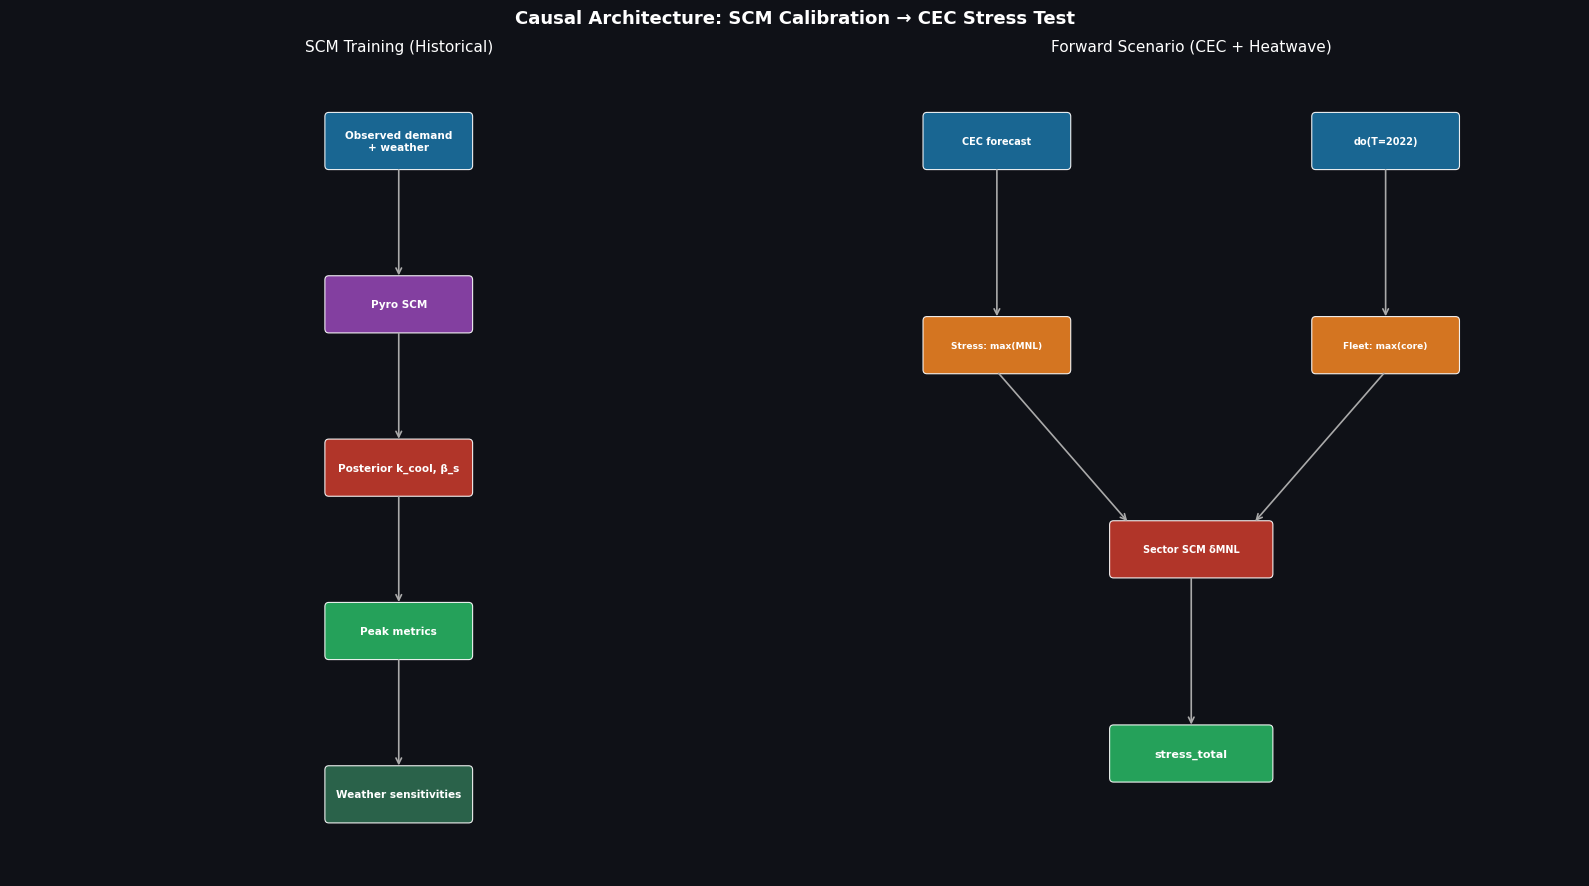

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 9))
fig.patch.set_facecolor('#0f1117')
for ax in axes:
    ax.set_facecolor('#0f1117')
    ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis('off')

from matplotlib.patches import FancyBboxPatch

def draw_node(ax, xy, label, color='#2d6a9f', size=0.55, fontsize=8):
    x, y = xy
    box = FancyBboxPatch((x-size, y-0.3), 2*size, 0.6, boxstyle='round,pad=0.05',
                          facecolor=color, edgecolor='white', linewidth=0.8, alpha=0.92)
    ax.add_patch(box)
    ax.text(x, y, label, ha='center', va='center', fontsize=fontsize, color='white', fontweight='bold')

def draw_arrow(ax, src, dst, color='#aaa'):
    ax.annotate('', xy=dst, xytext=src, arrowprops=dict(arrowstyle='->', color=color, lw=1.2))

ax = axes[0]
ax.set_title('SCM Training (Historical)', color='white', fontsize=11)
for xy, lbl, col in [((5,9),'Observed demand\n+ weather','#1a6e9e'),((5,7),'Pyro SCM','#8e44ad'),
    ((5,5),'Posterior k_cool, β_s','#c0392b'),((5,3),'Peak metrics','#27ae60'),((5,1),'Weather sensitivities','#2d6a4f')]:
    draw_node(ax, xy, lbl, col, 0.9, 7.5)
for y1,y2 in [(9,7),(7,5),(5,3),(3,1)]:
    draw_arrow(ax, (5,y1-0.32), (5,y2+0.32))

ax = axes[1]
ax.set_title('Forward Scenario (CEC + Heatwave)', color='white', fontsize=11)
draw_node(ax, (2.5,9), 'CEC forecast', '#1a6e9e', 0.9, 7)
draw_node(ax, (7.5,9), 'do(T=2022)', '#1a6e9e', 0.9, 7)
draw_node(ax, (2.5,6.5), 'Stress: max(MNL)', '#e67e22', 0.9, 6.5)
draw_node(ax, (7.5,6.5), 'Fleet: max(core)', '#e67e22', 0.9, 6.5)
draw_node(ax, (5,4), 'Sector SCM δMNL', '#c0392b', 1.0, 7)
draw_node(ax, (5,1.5), 'stress_total', '#27ae60', 1.0, 8)
for s,d in [((2.5,8.68),(2.5,6.82)),((7.5,8.68),(7.5,6.82)),((2.5,6.18),(4.2,4.32)),((7.5,6.18),(5.8,4.32)),((5,3.68),(5,1.82))]:
    draw_arrow(ax, s, d)

fig.suptitle('Causal Architecture: SCM Calibration → CEC Stress Test', color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(ANALYSIS / 'fig_policy_causal_dag.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()


## §7 — Stress & Headroom Visuals


In [9]:
fig_case_stress_band(cases, out_dir=ANALYSIS)
fig_headroom_erosion(cases, out_dir=ANALYSIS)
fig_sector_trajectories(cases['worst'], out_dir=ANALYSIS, title_suffix=' — Worst Case')
plt.show()


  Saved: fig_case_stress_band.png


  Saved: fig_headroom_erosion.png


  Saved: fig_sector_trajectories.png


## §8 — Policy Counterfactuals on Worst Case (Year-Native)
Industry interventions: **data centers** (PUE, off-peak shift), **EV fleets** (light-duty DR, MHDV depot DR), plus residential/industrial levers.


In [10]:
worst_peak_tbl = build_case_peak_table(hourly['LocalRel'], CASE_WORST)
worst_baseline = cases['worst']

cf_specs = build_scenarios(cal, peak_tables_co, primary_scenario='LocalRel')
DC_CAP_2030 = float(worst_peak_tbl.loc[2030, 'DATA_CENTER']) if 2030 in worst_peak_tbl.index else 4377.0

def dc_curtail(yr, dc_mw):
    return min(dc_mw * 0.70, DC_CAP_2030)

cf_specs['CF5'] = CounterfactualSpec(
    label='CF5: Combined policy stack',
    description='Industry stack + V2G + residential pre-cool + industrial interrupt',
    cal_overrides={'beta_ev': -0.20 * cal.beta_aafs},
    dc_adj_fn=dc_curtail,
    f_dc_scale=0.70,
    ev_adj_fn=lambda yr, lev, ldv: (lev * 0.15, ldv * 0.15),
    heavy_ev_adj_fn=lambda yr, h: h * 0.30,
    beta_ev_scale=0.0,
    beta_heavy_ev_scale=0.0,
    sector_beta_overrides={'RES': cal.beta['RES'] * 0.60, 'IND': 0.0},
)

INDUSTRY_KEYS = ['CF3', 'CF_DC_PUE', 'CF_DC_SHIFT', 'CF_EV_FLEET_DR', 'CF_HEAVY_EV_DR', 'CF_INDUSTRY_STACK']

cf_results = {}
for label, spec in cf_specs.items():
    cf_df = run_counterfactual(
        spec, worst_peak_tbl, cal, sector_shares_df, worst_baseline,
        uplift_method=UpliftMethod.YEAR_NATIVE, uplift_ctx=uplift_ctx,
    )
    cf_results[label] = cf_df

policy_years = [y for y in [2030, 2035, 2040, 2050] if y in worst_baseline.index]
policy_tbl = pd.DataFrame({'Worst baseline': worst_baseline.loc[policy_years, 'stress_total'].round(0)})
for label, df in cf_results.items():
    short = label.split(':')[0]
    policy_tbl[short] = df.loc[policy_years, 'stress_total'].round(0)
    policy_tbl[f'{short} ΔMW'] = (df.loc[policy_years, 'stress_total'] - worst_baseline.loc[policy_years, 'stress_total']).round(0)

print('=== Worst-case stress under each policy (MW) ===')
print(policy_tbl.to_string())
policy_tbl.to_csv(ANALYSIS / 'policy_worst_case_matrix.csv')

industry_cfs = {k: cf_results[k] for k in INDUSTRY_KEYS if k in cf_results}
industry_rows = []
for label, df in industry_cfs.items():
    for yr in policy_years:
        industry_rows.append({
            'policy': label.split(':')[0],
            'year': yr,
            'stress_mw': df.loc[yr, 'stress_total'],
            'delta_stress_mw': df.loc[yr, 'stress_total'] - worst_baseline.loc[yr, 'stress_total'],
            'delta_uplift_mw': df.loc[yr, 'd_total'] - worst_baseline.loc[yr, 'd_total'],
        })
pd.DataFrame(industry_rows).to_csv(ANALYSIS / 'industry_policy_matrix.csv', index=False)
print('\n=== Industry policies at 2035 ===')
print(pd.DataFrame(industry_rows)[pd.DataFrame(industry_rows)['year']==2035].to_string(index=False))


=== Worst-case stress under each policy (MW) ===
      Worst baseline      CF1  CF1 ΔMW     CF2a  CF2a ΔMW     CF2b  CF2b ΔMW      CF3  CF3 ΔMW  CF_RES_PRECOOL  CF_RES_PRECOOL ΔMW  CF_IND_INTERRUPT  CF_IND_INTERRUPT ΔMW  CF_TOU_SHOCK  CF_TOU_SHOCK ΔMW  CF_DC_PUE  CF_DC_PUE ΔMW  CF_DC_SHIFT  CF_DC_SHIFT ΔMW  CF_EV_FLEET_DR  CF_EV_FLEET_DR ΔMW  CF_HEAVY_EV_DR  CF_HEAVY_EV_DR ΔMW  CF_INDUSTRY_STACK  CF_INDUSTRY_STACK ΔMW      CF5  CF5 ΔMW
year                                                                                                                                                                                                                                                                                                                                                                                                  
2030         60062.0  60067.0      5.0  60045.0     -17.0  60036.0     -25.0  60039.0    -23.0         59669.0              -393.0           59983.0                 -79.

In [11]:
fig_counterfactual_matrix(worst_baseline, cf_results, out_dir=ANALYSIS, target_year=2035)
fig_industry_policy_matrix(worst_baseline, industry_cfs, out_dir=ANALYSIS, target_year=2035)
fig_mitigation_waterfall(worst_baseline, cf_results, out_dir=ANALYSIS, target_year=2035)
plt.show()


  Saved: fig_counterfactual_matrix.png


  Saved: fig_industry_policy_matrix.png


  Saved: fig_mitigation_waterfall.png


## §9 — Validation & Sensitivity


In [12]:
from pipeline.scm.trajectories import compute_all_trajectories
co_trajs = compute_all_trajectories(peak_tables_co, cal, sector_shares_df)
validation_results = run_all_validations(cal, co_trajs, peak_tables_co, sector_shares_df)

print('=== Structural validation checks ===')
for r in validation_results:
    print(r)
    print()

if 2030 in cases['average'].index:
    print('=== 2030 δMNL sensitivity to sampling ===')
    print(f"  Average:  {cases['average'].loc[2030,'d_total']:,.0f} MW")
    print(f"  Worst:    {cases['worst'].loc[2030,'d_total']:,.0f} MW")
    print(f"  Envelope: {cases['envelope'].loc[2030,'d_total']:,.0f} MW")



════════════════════════════════════════════════════════════════════════
══════════════════════ PIPELINE VALIDATION REPORT ══════════════════════
════════════════════════════════════════════════════════════════════════
  [✓] Check 1: Conservation of MW — Calibration Anchor  →  PASS
      Disaggregated 2025 components sum to 4,625.000 MW (target 4,625 MW, Δ=0.0000 MW).
      HVAC structural (MW): +1,529.43
      AAFS (MW): +0.00
      EV fleet (MW): +0.95
      DC thermal (MW): +1.48
      Residual/lag (MW): +3,093.13
      Sum (MW): 4,625.000
      Target (MW): 4,625
      Discrepancy (MW): 0.0000
      Tolerance (MW): ±1.0
      β_RES (MW/MW/°F): 0.003583
      β_COM (MW/MW/°F): 0.001792
      β_IND (MW/MW/°F): 0.000358

  [✓] Check 2: Physical Feasibility — Capacity Saturation  →  PASS
      No capacity ceiling breaches detected across all scenarios and years.

  [✓] Check 3: Structural Divergence — Dynamic vs Static  →  PASS
      Dynamic model diverges 8.53% from static by 2050 (+

## §10 — Findings & Hypothesis Check


In [13]:
findings = []
if 2035 in cases['worst'].index and 2035 in cases['best'].index:
    h1 = cases['worst'].loc[2035,'headroom_mw'] - cases['best'].loc[2035,'headroom_mw']
    findings.append(f'H1: 2035 headroom gap best vs worst = {h1:+,.0f} MW')
w35 = cases['worst'].loc[2035]
findings.append(f"H2: worst 2035 HVAC={w35['d_hvac_total']/w35['d_total']*100:.0f}% lag={w35['d_residual']/w35['d_total']*100:.0f}% of δMNL")
if 'year_native' in method_cmp and 'static_2022' in method_cmp:
    yn35 = method_cmp['year_native'].loc[2035,'d_total'] - method_cmp['static_2022'].loc[2035,'d_total']
    findings.append(f'Year-native vs static 2035 δMNL excess = {yn35:+,.0f} MW')
if 'CF_INDUSTRY_STACK' in cf_results:
    ind = float(cf_results['CF_INDUSTRY_STACK'].loc[2035,'stress_total'] - worst_baseline.loc[2035,'stress_total'])
    findings.append(f'Industry stack 2035 stress reduction = {ind:+,.0f} MW')
if 'CF_EV_FLEET_DR' in cf_results and 'CF_DC_PUE' in cf_results:
    ev = float(cf_results['CF_EV_FLEET_DR'].loc[2035,'vs_baseline'])
    dc = float(cf_results['CF_DC_PUE'].loc[2035,'vs_baseline'])
    findings.append(f'2035 uplift Δ: EV fleet DR={ev:+,.0f} MW  DC PUE={dc:+,.0f} MW')
if 'CF5' in cf_results:
    findings.append(f"H4: |CF5 vs baseline 2035| = {abs(cf_results['CF5'].loc[2035,'vs_baseline']):,.0f} MW δMNL")

for f in findings:
    print(' •', f)
for key, df in cases.items():
    df.to_csv(ANALYSIS / f'case_trajectory_{key}.csv')
print(f'\nOutputs → {ANALYSIS}/')


 • H1: 2035 headroom gap best vs worst = -7,014 MW
 • H2: worst 2035 HVAC=26% lag=69% of δMNL
 • Year-native vs static 2035 δMNL excess = +722 MW
 • Industry stack 2035 stress reduction = -113 MW
 • 2035 uplift Δ: EV fleet DR=-38 MW  DC PUE=-45 MW
 • H4: |CF5 vs baseline 2035| = 555 MW δMNL

Outputs → /home/ratth/projects/EnergyForecast/analysis/
